# EPL MVP Prediction
FBref(soccerdata) + Understat + FPL 데이터를 결합하여 PFA Player of the Year 수상자를 ML로 예측하고 SHAP으로 분석

## 0. 라이브러리 설치

In [ ]:
# 아래 명령어를 Anaconda Prompt에서 실행 후 커널 재시작하세요:
# conda install -c conda-forge shap xgboost lightgbm soccerdata -y
# pip install understatapi

# 설치 확인
import importlib
for pkg in ['soccerdata', 'shap', 'xgboost', 'lightgbm', 'understatapi']:
    found = importlib.util.find_spec(pkg) is not None
    print(f'{pkg:15s}: {"✓" if found else "✗ 미설치"}')

In [7]:
%pip install soccerdata

  Using cached soccerdata-1.9.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached html5lib-1.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached seleniumbase-4.48.1-py3-none-any.whl.metadata (88 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached Unidecode-1.4.0-py3-none-any.whl.metadata (13 kB)
  Using cached wrapper_tls_requests-1.2.5-py3-none-any.whl.metadata (8.6 kB)
  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached packaging-26.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached exceptiongroup-1.3.1-py3-none-any.whl.metadata (6.7 kB)
  Using cached filelock-3.28.0-py3-none-any.whl.metadata (2.0 kB)
  Using c

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpcore 1.0.2 requires h11<0.15,>=0.13, but you have h11 0.16.0 which is incompatible.
mdit-py-plugins 0.3.0 requires markdown-it-py<3.0.0,>=1.0.0, but you have markdown-it-py 4.0.0 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.1 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


## 1. 데이터 수집

### 1-1. FBref 데이터 (soccerdata)
xG, npxG, xAG, 프로그레시브 패스, 수비 액션 등 ~100개 피처

In [99]:
import soccerdata as sd
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

SEASONS = list(range(2014, 2025))  # 2014-15 ~ 2023-24 (FBref 지원 범위)

fbref = sd.FBref(leagues='ENG-Premier League', seasons=SEASONS)

STAT_TYPES = ['standard', 'keeper', 'shooting', 'playing_time', 'misc']

fbref_dfs = {}
for stat in STAT_TYPES:
    print(f'Fetching {stat}...')
    fbref_dfs[stat] = fbref.read_player_season_stats(stat_type=stat)

print('FBref 수집 완료')

[04/17/26 02:34:56] INFO     Saving cached data to C:\Users\tnsru\soccerdata\data\FBref              ]8;id=14446578;file://c:\Users\tnsru\anaconda3\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=14446579;file://c:\Users\tnsru\anaconda3\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Fetching standard...
Fetching keeper...
Fetching shooting...
Fetching playing_time...
Fetching misc...
FBref 수집 완료


In [100]:
# 멀티인덱스 컬럼 평탄화 후 전체 stat 병합
def flatten_cols(df):
    df = df.copy()
    df.columns = ['_'.join(c).strip('_') if isinstance(c, tuple) else c for c in df.columns]
    return df

df_fbref = flatten_cols(fbref_dfs['standard']).reset_index()

for stat in STAT_TYPES[1:]:
    df_tmp = flatten_cols(fbref_dfs[stat]).reset_index()
    # player + season 키 이외 중복 컬럼 제거
    dup = set(df_fbref.columns) & set(df_tmp.columns) - {'player', 'season'}
    df_tmp = df_tmp.drop(columns=list(dup))
    df_fbref = df_fbref.merge(df_tmp, on=['player', 'season'], how='left')

print(f'FBref 병합 완료: {df_fbref.shape}')
df_fbref.head(3)

FBref 병합 완료: (7149, 75)


,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_PKcon,Performance_OG
0,ENG-Premier League,1415,Arsenal,Aaron Ramsey,WAL,MF,23,1990,29,23,...,<NA>,22,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,ENG-Premier League,1415,Arsenal,Ainsley Maitland-Niles,ENG,"DF,FW",16,1997,1,0,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,ENG-Premier League,1415,Arsenal,Alex Oxlade-Chamberlain,ENG,"FW,MF",20,1993,23,17,...,<NA>,14,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [101]:
import os

SAVE_DIR = 'data'
os.makedirs(SAVE_DIR, exist_ok=True)

# 각 stat별 원본 저장
for stat, df_tmp in fbref_dfs.items():
    df_tmp.to_csv(f'{SAVE_DIR}/fbref_{stat}.csv', encoding='utf-8-sig')
    print(f'저장 완료: {SAVE_DIR}/fbref_{stat}.csv  {df_tmp.shape}')

print('\n모든 FBref 데이터 저장 완료')

저장 완료: data/fbref_standard.csv  (5467, 21)
저장 완료: data/fbref_keeper.csv  (412, 23)
저장 완료: data/fbref_shooting.csv  (5467, 15)
저장 완료: data/fbref_playing_time.csv  (6577, 21)
저장 완료: data/fbref_misc.csv  (5467, 17)

모든 FBref 데이터 저장 완료


### 1-2. Understat 데이터 (xGChain, xGBuildup)
팀 공격 관여도를 측정하는 xGChain / xGBuildup 포함

In [102]:
from understatapi import UnderstatClient

client = UnderstatClient()
rows = []

for season in range(2014, 2026):  # 2014-15 ~ 2023-24
    print(f'Understat {season}-{season+1} 수집 중...')
    players = client.league(league='EPL').get_player_data(season=str(season))
    for p in players:
        p['season_year'] = season
        rows.append(p)

df_understat_raw = pd.DataFrame(rows)
print(f'Understat 수집 완료: {df_understat_raw.shape}')
df_understat_raw.head(3)

Understat 2014-2015 수집 중...
Understat 2015-2016 수집 중...
Understat 2016-2017 수집 중...
Understat 2017-2018 수집 중...
Understat 2018-2019 수집 중...
Understat 2019-2020 수집 중...
Understat 2020-2021 수집 중...
Understat 2021-2022 수집 중...
Understat 2022-2023 수집 중...
Understat 2023-2024 수집 중...
Understat 2024-2025 수집 중...
Understat 2025-2026 수집 중...
Understat 수집 완료: (6410, 19)


,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season_year
0,619,Sergio Agüero,33,2551,26,25.270175583660603,8,5.568926602602005,148,33,4,0,F S,Manchester City,21,20.703194603323936,27.805153466761112,6.87816970795393,2014
1,647,Harry Kane,34,2589,21,17.15730034559965,4,3.9225024580955505,112,27,4,0,F M S,Tottenham,19,14.87382235378027,16.48843494337052,5.549698708578944,2014
2,802,Diego Costa,26,2111,20,15.21911308169365,3,4.554670616053045,76,41,8,0,F S,Chelsea,19,14.457944065332413,21.365789726376534,5.27697273902595,2014


In [103]:
# Understat 컬럼 정리 & FBref season 형식('1819')에 맞춤
us_cols = ['player_name', 'season_year', 'xGChain', 'xGBuildup', 'xG', 'xA', 'npxG', 'shots', 'key_passes']
df_understat = df_understat_raw[us_cols].copy()
df_understat.columns = ['player', 'season_year'] + [f'us_{c}' for c in us_cols[2:]]

# 2017 → '1718', 2018 → '1819' 형식으로 변환
df_understat['season'] = df_understat['season_year'].apply(
    lambda y: f'{str(y)[2:]}{str(y+1)[2:]}'
)
df_understat = df_understat.drop(columns='season_year')

for col in df_understat.columns[1:-1]:
    df_understat[col] = pd.to_numeric(df_understat[col], errors='coerce')

print('시즌 샘플:', df_understat['season'].unique())
df_understat.head(3)

시즌 샘플: <ArrowStringArray>
['1415', '1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223',
 '2324', '2425', '2526']
Length: 12, dtype: str


,player,us_xGChain,us_xGBuildup,us_xG,us_xA,us_npxG,us_shots,us_key_passes,season
0,Sergio Agüero,27.805153,6.878170,25.270176,5.568927,20.703195,148,33,1415
1,Harry Kane,16.488435,5.549699,17.157300,3.922502,14.873822,112,27,1415
2,Diego Costa,21.365790,5.276973,15.219113,4.554671,14.457944,76,41,1415


### 1-3. FPL 데이터 (ICT Index, 소유율 등)
팬/전문가 집단지성 신호로 활용

In [104]:
import requests
import io

FPL_SEASON_MAP = {
    '1617': '2016-17',
    '1718': '2017-18',
    '1819': '2018-19',
    '1920': '2019-20',
    '2021': '2020-21',
    '2122': '2021-22',
    '2223': '2022-23',
    '2324': '2023-24',
}

BASE_URL = 'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/cleaned_players.csv'

fpl_frames = []
for fbref_season, fpl_season in FPL_SEASON_MAP.items():
    url = BASE_URL.format(season=fpl_season)
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        df_tmp = pd.read_csv(io.StringIO(r.text))
        df_tmp['season'] = fbref_season
        fpl_frames.append(df_tmp)
        print(f'FPL {fpl_season} 완료 ({len(df_tmp)}명)')
    except Exception as e:
        print(f'FPL {fpl_season} 실패: {e}')

df_fpl_raw = pd.concat(fpl_frames, ignore_index=True)
print(f'\nFPL 수집 완료: {df_fpl_raw.shape}')
df_fpl_raw.head(3)

FPL 2016-17 완료 (683명)
FPL 2017-18 완료 (647명)
FPL 2018-19 완료 (624명)
FPL 2019-20 완료 (666명)
FPL 2020-21 완료 (713명)
FPL 2021-22 완료 (737명)
FPL 2022-23 완료 (778명)
FPL 2023-24 완료 (865명)

FPL 수집 완료: (5713, 20)


,first_name,second_name,goals_scored,assists,total_points,minutes,goals_conceded,creativity,influence,threat,bonus,bps,ict_index,clean_sheets,red_cards,yellow_cards,selected_by_percent,season,now_cost,element_type
0,David,Ospina,0,0,2,143,4,0.0,28.8,0.0,0,18,2.9,0,0,0,0.2,1617,NaN,NaN
1,Petr,Cech,0,0,134,3097,37,0.1,819.8,0.0,2,660,82.0,12,0,2,13.7,1617,NaN,NaN
2,Laurent,Koscielny,2,1,121,2821,37,53.9,831.2,239.0,19,723,112.7,10,1,4,11.2,1617,NaN,NaN


In [105]:
# FPL 컬럼 정리
df_fpl = df_fpl_raw.copy()
df_fpl['player'] = df_fpl['first_name'].str.strip() + ' ' + df_fpl['second_name'].str.strip()

fpl_keep = ['player', 'season', 'ict_index', 'influence', 'creativity', 'threat',
            'bonus', 'bps', 'selected_by_percent', 'total_points', 'minutes']
fpl_keep = [c for c in fpl_keep if c in df_fpl.columns]

df_fpl = df_fpl[fpl_keep].copy()
# 접두사 추가
rename = {c: f'fpl_{c}' for c in fpl_keep if c not in ['player', 'season']}
df_fpl = df_fpl.rename(columns=rename)

for col in df_fpl.columns[2:]:
    df_fpl[col] = pd.to_numeric(df_fpl[col], errors='coerce')

df_fpl.head(3)

,player,season,fpl_ict_index,fpl_influence,fpl_creativity,fpl_threat,fpl_bonus,fpl_bps,fpl_selected_by_percent,fpl_total_points,fpl_minutes
0,David Ospina,1617,2.9,28.8,0.0,0.0,0,18,0.2,2,143
1,Petr Cech,1617,82.0,819.8,0.1,0.0,2,660,13.7,134,3097
2,Laurent Koscielny,1617,112.7,831.2,53.9,239.0,19,723,11.2,121,2821


### 1-4. PFA Player of the Year 레이블 (타겟 변수)

In [106]:
PFA_WINNERS = {
    '1415': 'Eden Hazard',
    '1516': 'Riyad Mahrez',
    '1617': "N'Golo Kanté",
    '1718': 'Mohamed Salah',
    '1819': 'Virgil van Dijk',   # 수정: Raheem Sterling → Virgil van Dijk
    '1920': 'Kevin De Bruyne',   # 수정: Jordan Henderson → Kevin De Bruyne
    '2021': 'Kevin De Bruyne',   # 수정: Rúben Dias → Kevin De Bruyne
    '2122': 'Mohamed Salah',     # 수정: Kevin De Bruyne → Mohamed Salah
    '2223': 'Erling Haaland',
    '2324': 'Phil Foden',        # 수정: Cole Palmer → Phil Foden
    '2425': 'Mohamed Salah',     # 추가
}

df_pfa = pd.DataFrame([
    {'player': name, 'season': season, 'pfa_winner': 1}
    for season, name in PFA_WINNERS.items()
])

print(df_pfa)

             player season  pfa_winner
0       Eden Hazard   1415           1
1      Riyad Mahrez   1516           1
2      N'Golo Kanté   1617           1
3     Mohamed Salah   1718           1
4   Virgil van Dijk   1819           1
5   Kevin De Bruyne   1920           1
6   Kevin De Bruyne   2021           1
7     Mohamed Salah   2122           1
8    Erling Haaland   2223           1
9        Phil Foden   2324           1
10    Mohamed Salah   2425           1


## 2. 데이터 병합

In [107]:
# 이적 선수 중복 처리: 같은 player+season이 여러 팀으로 나뉜 경우 수치형 컬럼 합산
num_cols = df_fbref.select_dtypes(include='number').columns.tolist()
df_fbref_dedup = (
    df_fbref.groupby(['player', 'season'], as_index=False)[num_cols].sum()
)

df = df_fbref_dedup.copy()
df = df.merge(df_understat, on=['player', 'season'], how='left')
df = df.merge(df_fpl,       on=['player', 'season'], how='left')
df = df.merge(df_pfa,       on=['player', 'season'], how='left')
df['pfa_winner'] = df['pfa_winner'].fillna(0).astype(int)

print(f'최종 데이터셋: {df.shape}')
print(f'PFA 수상자 매칭 수: {df["pfa_winner"].sum()} / {len(PFA_WINNERS)}')
df[df['pfa_winner'] == 1][['player', 'season', 'pfa_winner']]

최종 데이터셋: (5355, 88)
PFA 수상자 매칭 수: 10 / 11


,player,season,pfa_winner
1448,Eden Hazard,1415,1
1572,Erling Haaland,2223,1
2889,Kevin De Bruyne,1920,1
2890,Kevin De Bruyne,2021,1
3696,Mohamed Salah,1718,1
3702,Mohamed Salah,2425,1
3764,N'Golo Kanté,1617,1
4153,Phil Foden,2324,1
4307,Riyad Mahrez,1516,1
5078,Virgil van Dijk,1819,1


In [108]:
# 병합된 최종 데이터셋 저장
df.to_csv(f'{SAVE_DIR}/epl_mvp_dataset.csv', index=False, encoding='utf-8-sig')
df.to_excel(f'{SAVE_DIR}/epl_mvp_dataset.xlsx', index=False)
print(f'저장 완료: {SAVE_DIR}/epl_mvp_dataset.csv / .xlsx  {df.shape}')

저장 완료: data/epl_mvp_dataset.csv / .xlsx  (5355, 88)


## 3. 피처 엔지니어링 & 전처리

In [110]:
from sklearn.impute import SimpleImputer

# 문자열/메타 컬럼 제외
exclude = {'player', 'season', 'pfa_winner'}
exclude |= {c for c in df.columns if df[c].dtype == object}

feature_cols = [c for c in df.columns
                if c not in exclude
                and pd.api.types.is_numeric_dtype(df[c])]

# 결측치 50% 초과 컬럼 제거
thresh = len(df) * 0.5
feature_cols = [c for c in feature_cols if df[c].notna().sum() > thresh]

X = df[feature_cols].copy()
y = df['pfa_winner'].copy()

# 결측치 중앙값으로 대체
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

print(f'피처 수: {len(feature_cols)}')
print(f'샘플 수: {len(X_imp)}')
print(f'수상자 수: {y.sum()}명')

피처 수: 85
샘플 수: 5355
수상자 수: 10명


## 4. ML 모델 학습 및 비교

In [111]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

n_pos = int(y.sum())
print(f'수상자(positive) 수: {n_pos}명')

# positive 샘플 수보다 fold가 많으면 안 됨
n_splits = min(n_pos, 5)
if n_splits < 2:
    raise ValueError(f'PFA 수상자 매칭이 {n_pos}명뿐입니다. 이름 매칭을 확인하세요.')
print(f'CV folds: {n_splits}')

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
pos_weight = (len(y) - y.sum()) / y.sum()

models = {
    'RandomForest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'XGBoost':            xgb.XGBClassifier(n_estimators=300, scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss'),
    'LightGBM':           lgb.LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=42, verbose=-1),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

results = {}
for name, model in models.items():
    X_in = X_scaled if name == 'LogisticRegression' else X_imp.values
    try:
        scores = cross_val_score(model, X_in, y, cv=cv, scoring='roc_auc')
        results[name] = scores
        print(f'{name:25s}  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    except Exception as e:
        print(f'{name:25s}  오류: {e}')

수상자(positive) 수: 10명
CV folds: 5
RandomForest               ROC-AUC: 0.9383 ± 0.1005
XGBoost                    ROC-AUC: 0.9371 ± 0.0780
LightGBM                   ROC-AUC: 0.8964 ± 0.0978
GradientBoosting           ROC-AUC: 0.6799 ± 0.2432
LogisticRegression         ROC-AUC: 0.8944 ± 0.1718


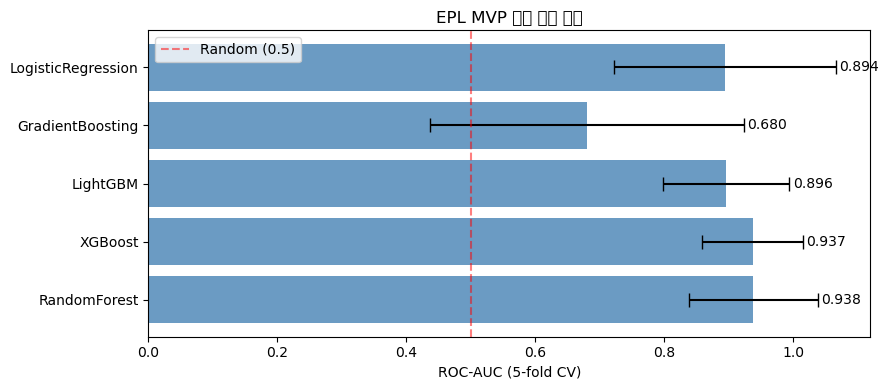

In [112]:
# 모델 성능 비교 시각화
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results.keys())
means = [v.mean() for v in results.values()]
stds  = [v.std()  for v in results.values()]

bars = ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8, capsize=5)
ax.set_xlabel('ROC-AUC (5-fold CV)')
ax.set_title('EPL MVP 예측 모델 비교')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.legend()
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.005, i, f'{m:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 5. SHAP 분석

In [113]:
import shap

# XGBoost 전체 데이터로 재학습 후 SHAP 계산
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_imp, y)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_imp)

print('SHAP 계산 완료')

SHAP 계산 완료


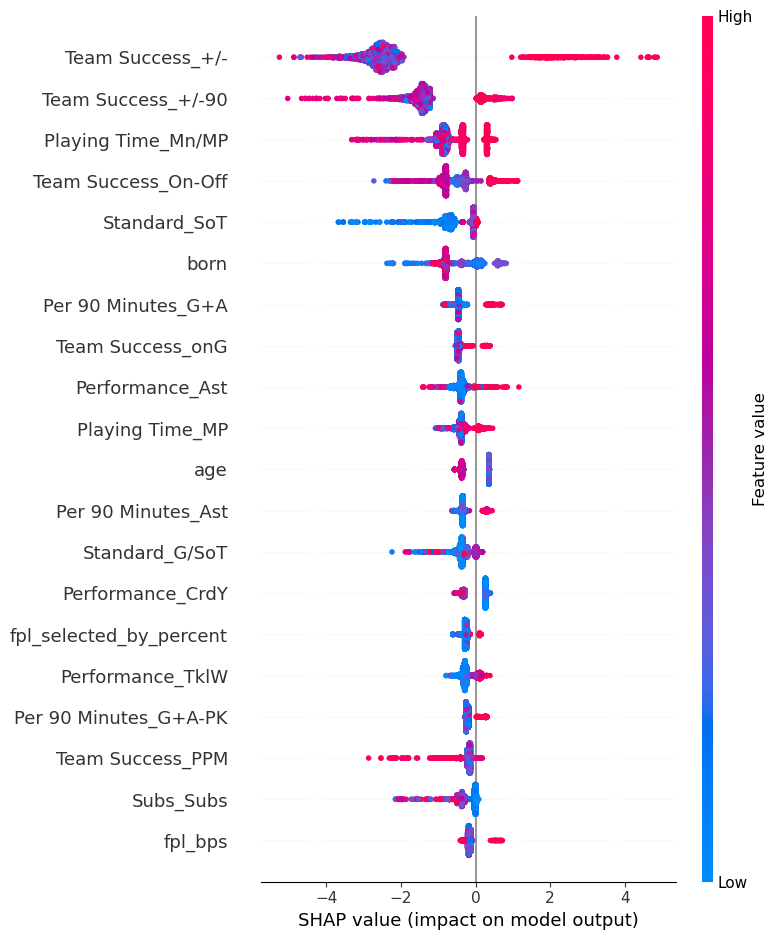

In [94]:
# Summary Plot — 피처별 중요도 + 값 방향 한눈에 보기
shap.summary_plot(shap_values, X_imp, feature_names=feature_cols, max_display=20)

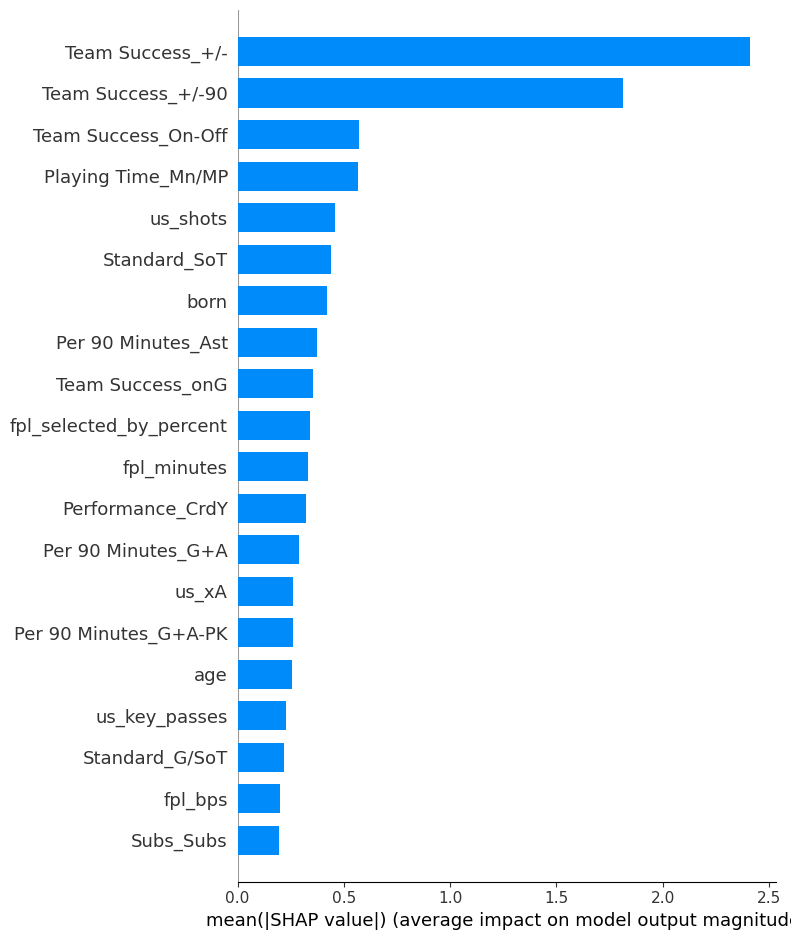

In [114]:
# Bar Plot — 평균 절대 SHAP 기준 피처 중요도
shap.summary_plot(shap_values, X_imp, feature_names=feature_cols, plot_type='bar', max_display=20)


--- Eden Hazard (1415) ---


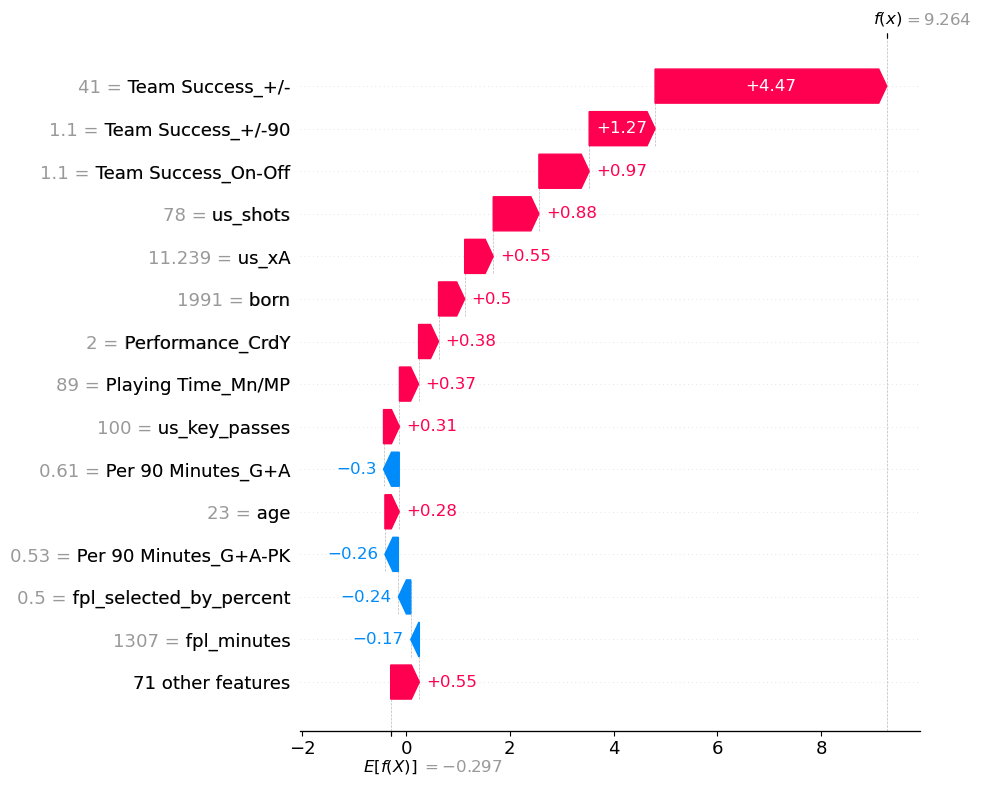


--- Erling Haaland (2223) ---


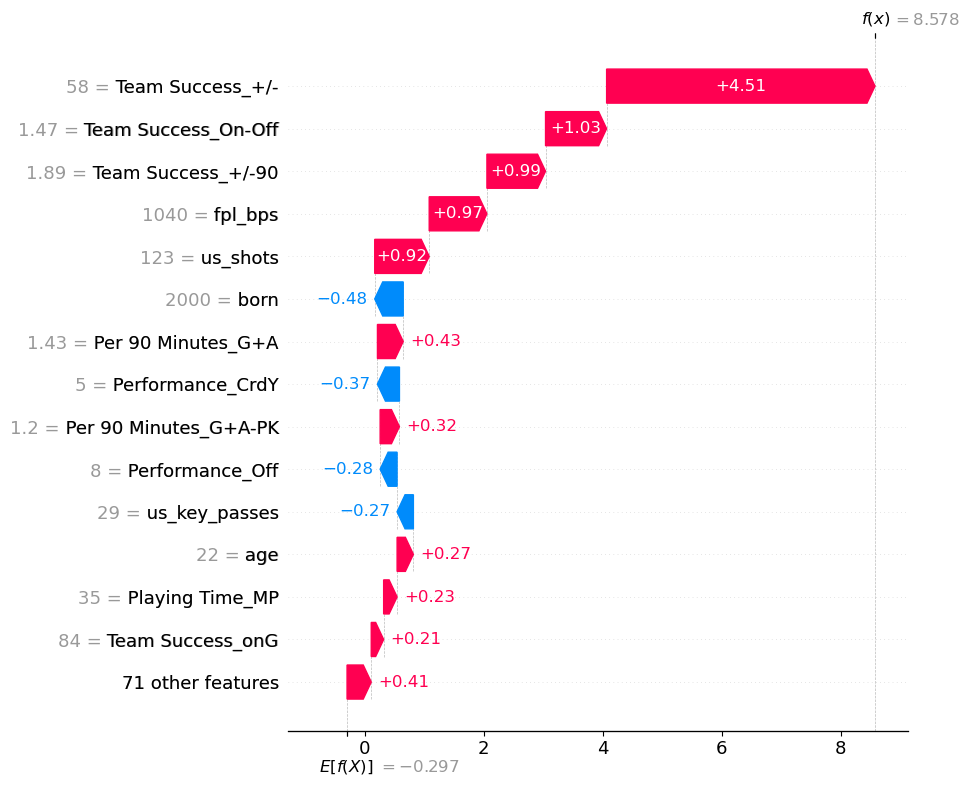


--- Kevin De Bruyne (1920) ---


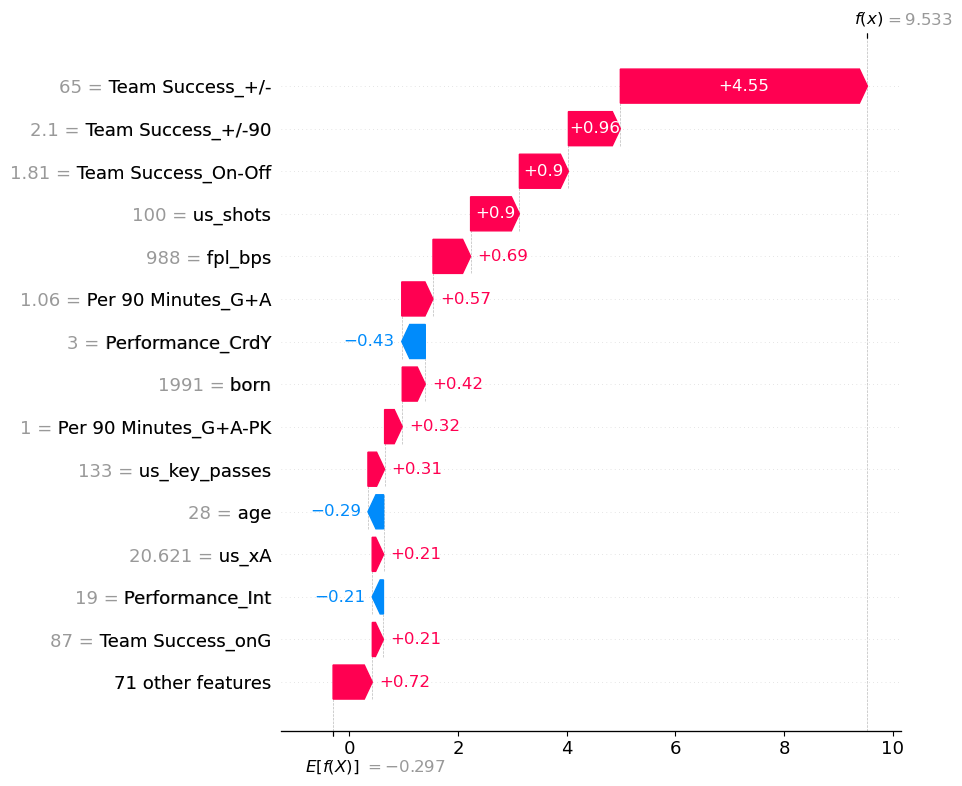


--- Kevin De Bruyne (2021) ---


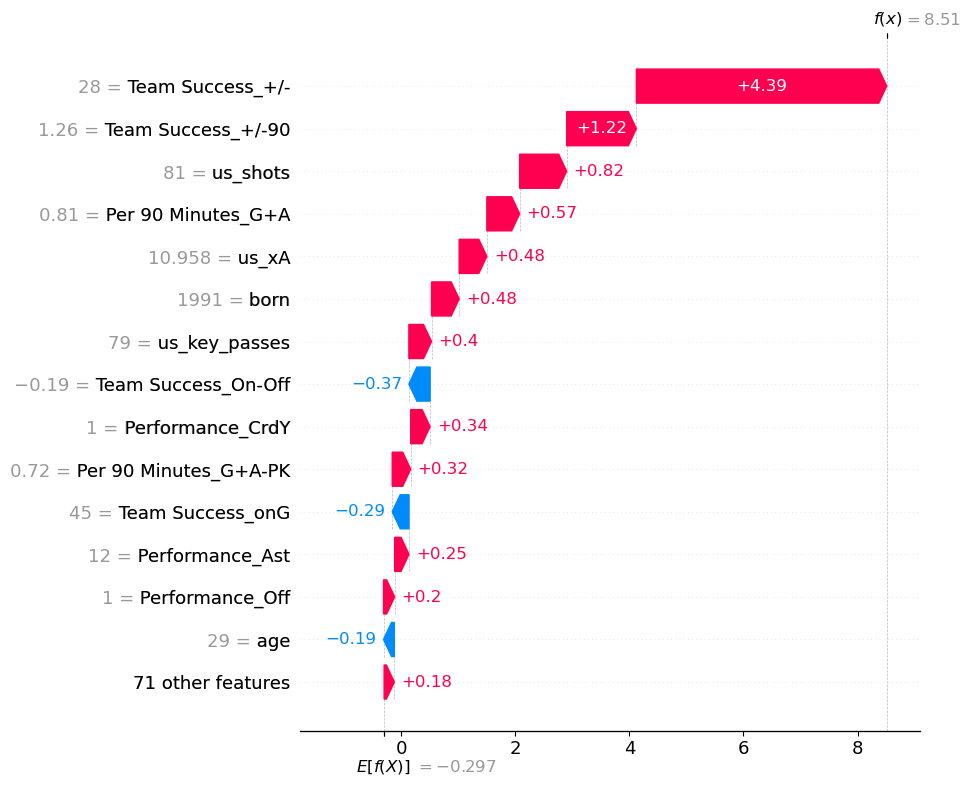


--- Mohamed Salah (1718) ---


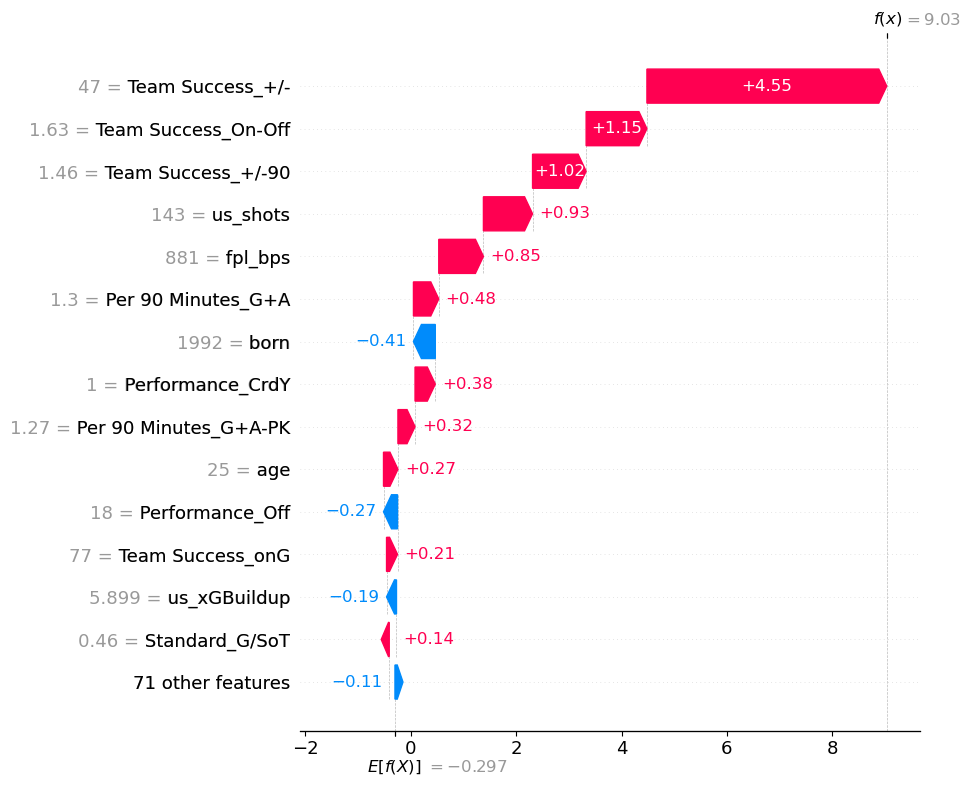


--- Mohamed Salah (2425) ---


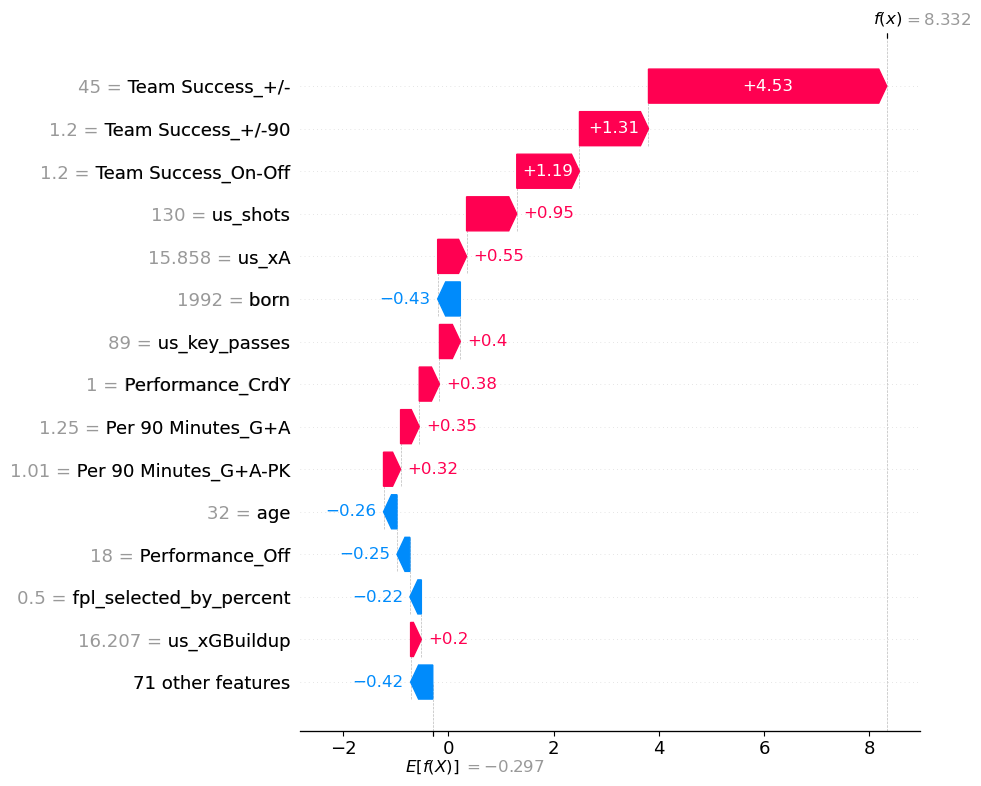


--- N'Golo Kanté (1617) ---


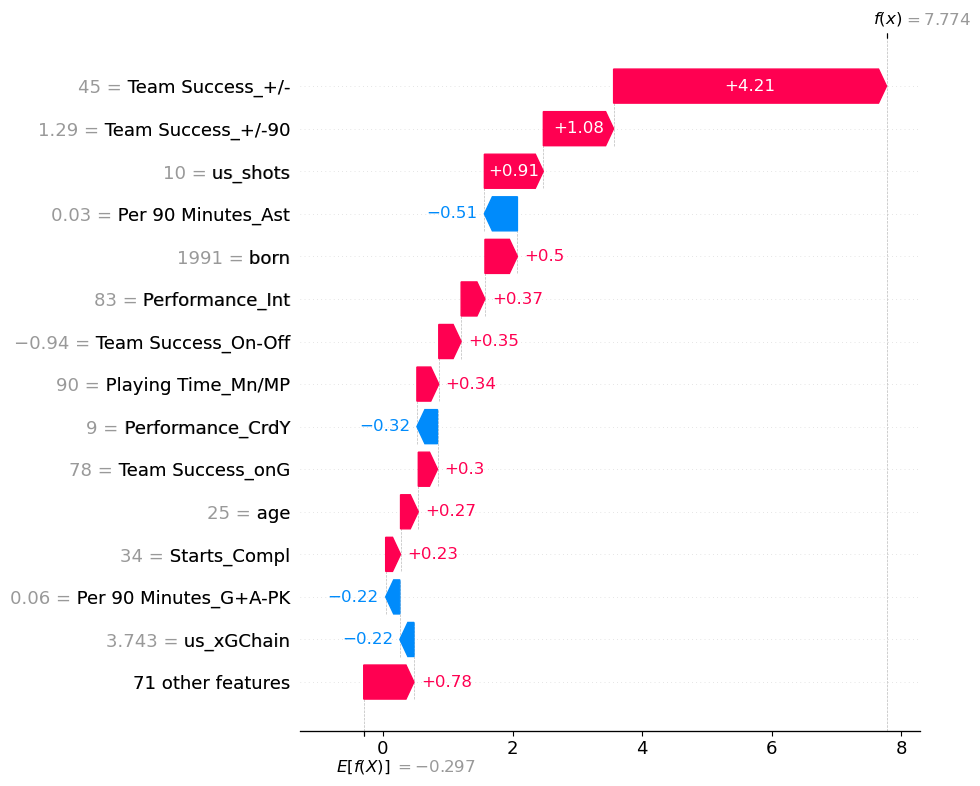


--- Phil Foden (2324) ---


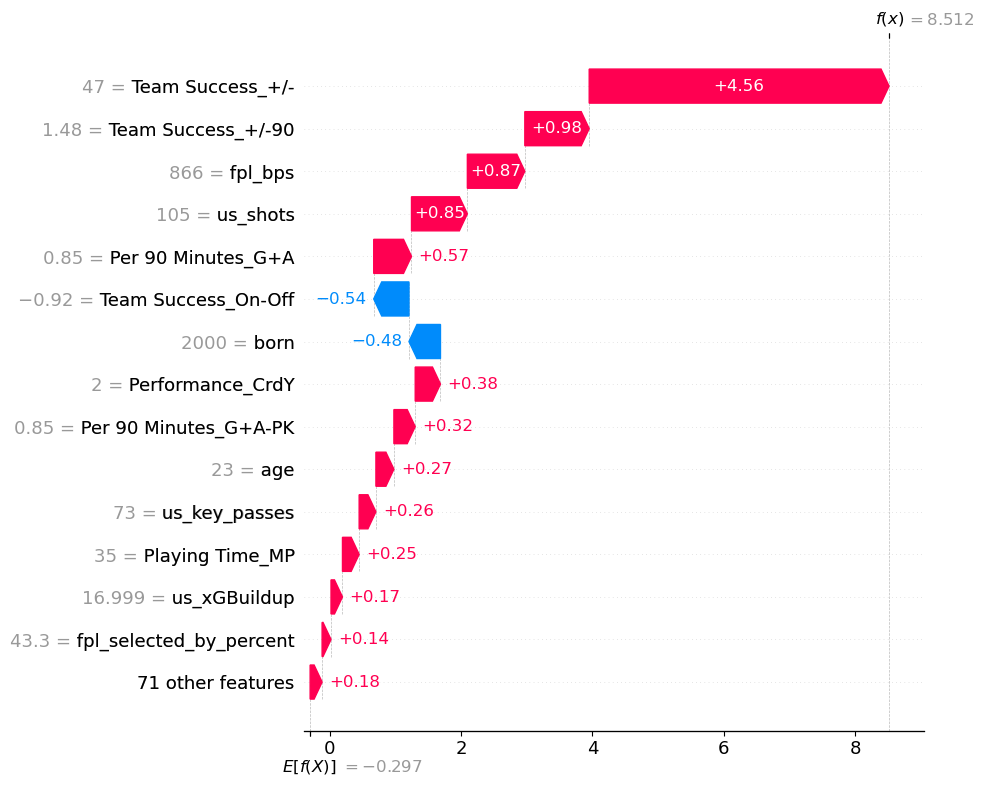


--- Riyad Mahrez (1516) ---


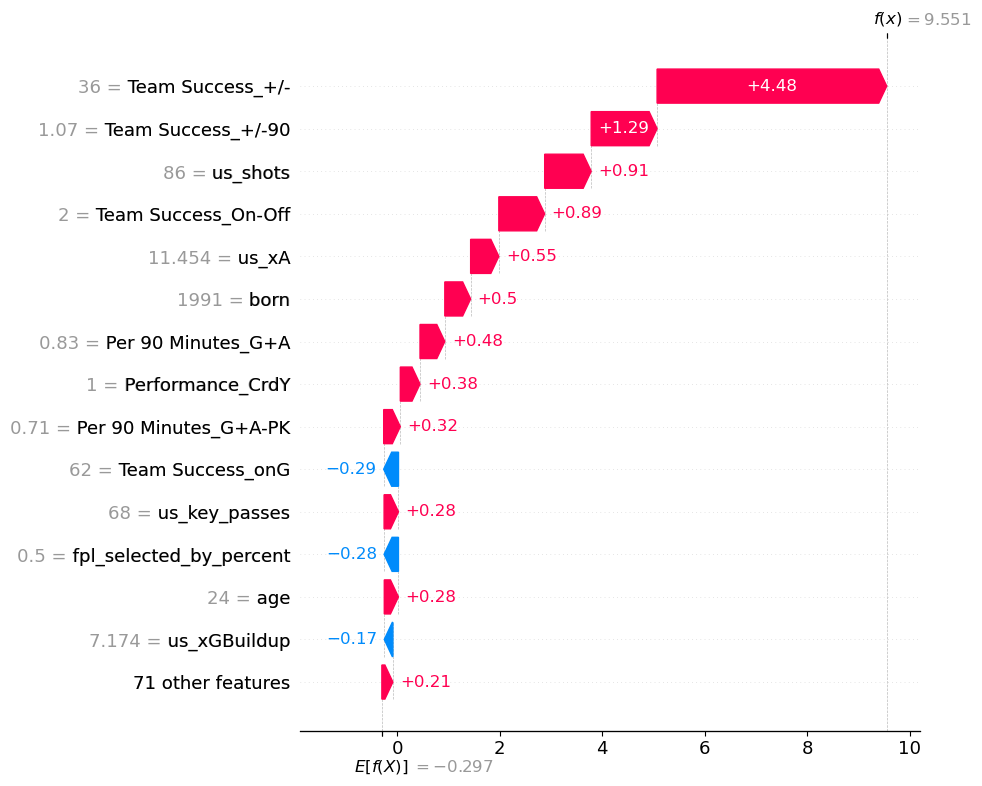


--- Virgil van Dijk (1819) ---


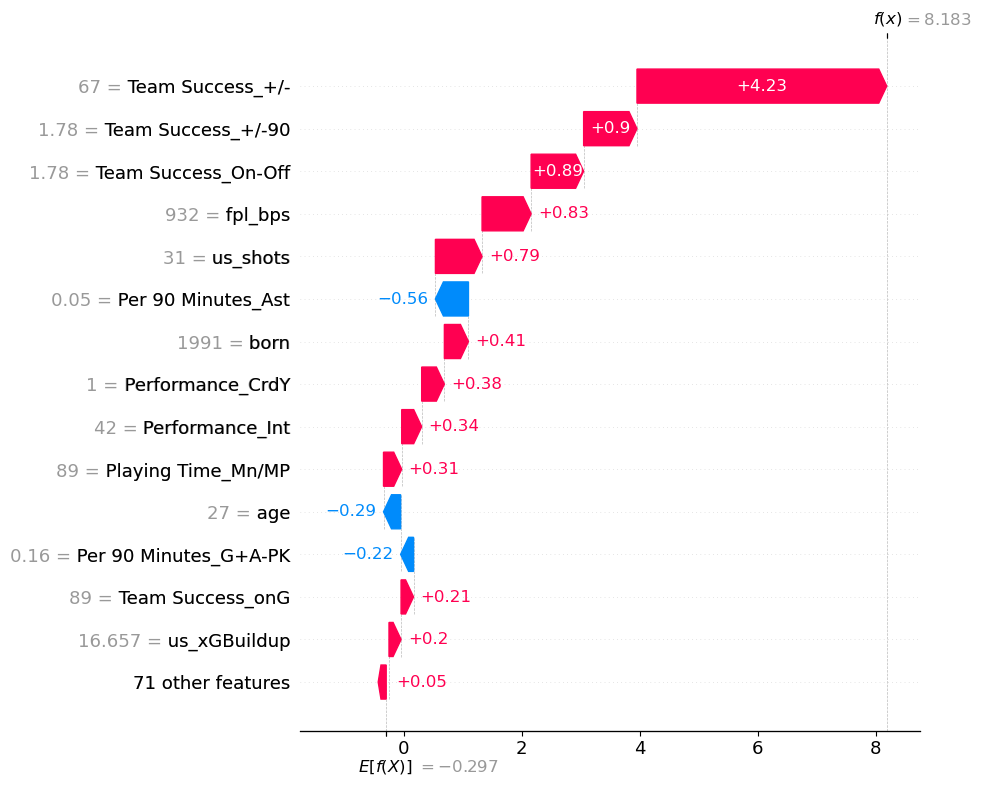

In [115]:
# Waterfall Plot — 수상자별 예측 근거 (왜 이 선수가 MVP로 예측됐는가)
winner_indices = df[df['pfa_winner'] == 1].index.tolist()

for idx in winner_indices:
    player = df.loc[idx, 'player']
    season = df.loc[idx, 'season']
    print(f'\n--- {player} ({season}) ---')
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_imp.iloc[idx].values,
            feature_names=feature_cols
        ),
        max_display=15
    )

가장 중요한 피처: Team Success_+/-


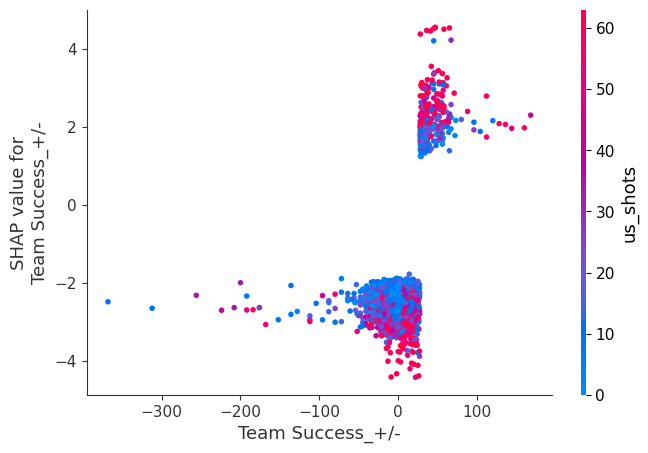

In [116]:
# Dependence Plot — 가장 중요한 피처의 영향과 상호작용 확인
top_feat = feature_cols[np.abs(shap_values).mean(axis=0).argmax()]
print(f'가장 중요한 피처: {top_feat}')
shap.dependence_plot(top_feat, shap_values, X_imp, feature_names=feature_cols)

## 6. 시즌별 MVP 예측 확률 Top 10

In [118]:
import os

df['mvp_prob'] = xgb_model.predict_proba(X_imp)[:, 1]

output_lines = []
for season in sorted(df['season'].unique()):
    top10 = (
        df[df['season'] == season]
        .nlargest(10, 'mvp_prob')[['player', 'season', 'mvp_prob', 'pfa_winner']]
        .reset_index(drop=True)
    )
    top10.index += 1
    top10['mvp_prob'] = top10['mvp_prob'].map('{:.4f}'.format)
    top10['pfa_winner'] = top10['pfa_winner'].map({1: '★ 수상', 0: ''})
    block = f'\n=== {season} ===\n{top10.to_string()}'
    output_lines.append(block)

full_output = '\n'.join(output_lines)

# 텍스트 파일로 저장
os.makedirs('data', exist_ok=True)
with open('data/mvp_prediction_results.txt', 'w', encoding='utf-8') as f:
    f.write(full_output)

print(full_output)
print('\n\n결과 저장 완료: data/mvp_prediction_results.txt')


=== 1415 ===
                player season mvp_prob pfa_winner
1          Eden Hazard   1415   0.9999       ★ 수상
2        Wilfried Bony   1415   0.0468           
3        Sergio Agüero   1415   0.0218           
4        Cesc Fàbregas   1415   0.0033           
5   Branislav Ivanović   1415   0.0019           
6                Oscar   1415   0.0016           
7           John Terry   1415   0.0014           
8             Joe Hart   1415   0.0012           
9            Jack Cork   1415   0.0007           
10        Theo Walcott   1415   0.0006           

=== 1516 ===
                 player season mvp_prob pfa_winner
1          Riyad Mahrez   1516   0.9999       ★ 수상
2     Christian Eriksen   1516   0.0114           
3            Harry Kane   1516   0.0011           
4             Dele Alli   1516   0.0009           
5       Andros Townsend   1516   0.0005           
6            Mesut Özil   1516   0.0004           
7   Sébastien Pocognoli   1516   0.0004           
8        Matth

In [119]:
print('FBref 시즌 목록:', sorted(df_fbref['season'].unique()))

FBref 시즌 목록: ['1415', '1516', '1617', '1718', '1819', '1920', '2021', '2223', '2324', '2425']


In [78]:
print(feature_cols)

['age', 'born', 'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', 'Performance_GA', 'Performance_GA90', 'Performance_SoTA', 'Performance_Saves', 'Performance_Save%', 'Performance_W', 'Performance_D', 'Performance_L', 'Performance_CS', 'Performance_CS%', 'Penalty Kicks_PKatt', 'Penalty Kicks_PKA', 'Penalty Kicks_PKsv', 'Penalty Kicks_PKm', 'Penalty Kicks_Save%', '90s', 'Standard_Gls', 'Standard_Sh', 'Standard_SoT', 'Standard_SoT%', 'Standard_Sh/90', 'Standard_SoT/90', 'Standard_G/Sh', 'Standard_G/SoT', 'Standard_PK', 'Standard_PKatt', 'Playing Time_Mn/MP', 'Playing Time_Min%', 'Starts_Starts', 'Starts_Mn/Start', 'Starts_Compl', 'Subs_Subs', 'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM', '